In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [25]:
train_df = pd.read_csv("data/mnist_train.csv")
test_df = pd.read_csv("data/mnist_test.csv")

In [26]:
train_df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
print("Training Shape :", train_df.shape)
print("Testing Shape :", test_df.shape)
train_df.info()

Training Shape : (60000, 785)
Testing Shape : (10000, 785)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


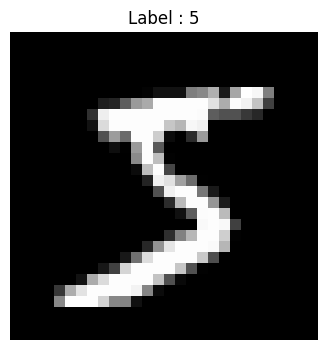

In [28]:
plt.figure(figsize=(4,4))
plt.imshow(train_df.iloc[0,1:].values.reshape(28,28), cmap='gray')
plt.title(f"Label : {train_df.iloc[0,0]}")
plt.axis('off')
plt.show()

In [29]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


In [30]:
X_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

X_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values

In [31]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [32]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [33]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

C:\Users\ayush\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [35]:
history = model.fit(X_train,y_train_cat,validation_data=(X_test, y_test_cat),epochs=10,batch_size=32,verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9286 - loss: 0.2437 - val_accuracy: 0.9589 - val_loss: 0.1337
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9689 - loss: 0.1031 - val_accuracy: 0.9728 - val_loss: 0.0900
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9772 - loss: 0.0716 - val_accuracy: 0.9767 - val_loss: 0.0793
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9818 - loss: 0.0551 - val_accuracy: 0.9741 - val_loss: 0.0849
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9861 - loss: 0.0440 - val_accuracy: 0.9767 - val_loss: 0.0819
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9886 - loss: 0.0352 - val_accuracy: 0.9787 - val_loss: 0.0747
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9902 - loss: 0.0285 - val_accuracy: 0.9784 - val_loss: 0.0789
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9921 - loss: 0.0249 - 

In [36]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9766 - loss: 0.1026
Test Accuracy : 0.9765999913215637


In [37]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step


In [38]:
print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.96      0.99      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



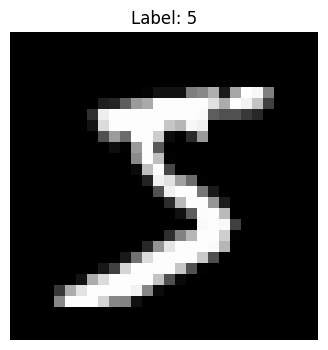

In [39]:
plt.figure(figsize=(4,4))
plt.imshow(train_df.iloc[0,1:].values.reshape(28,28), cmap="gray")
plt.title(f"Label: {train_df.iloc[0,0]}")
plt.axis("off")

plt.savefig("images/sample_digit.png", dpi=300, bbox_inches="tight")
plt.show()

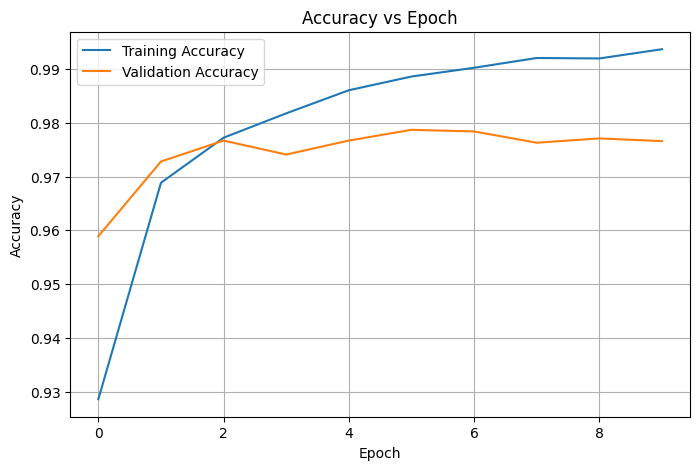

In [40]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("images/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

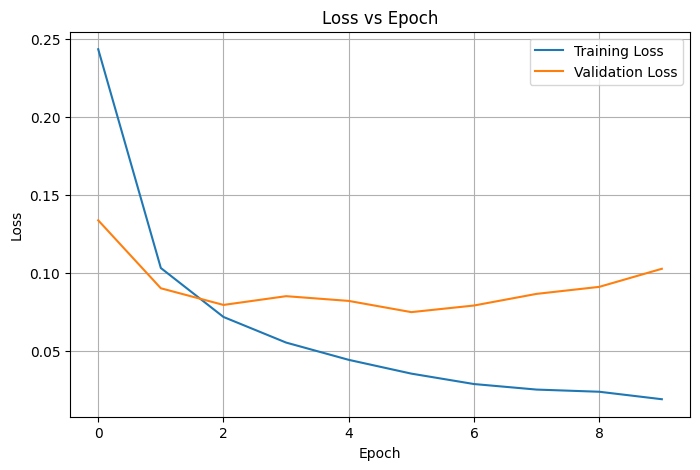

In [41]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("images/loss.png", dpi=300, bbox_inches="tight")
plt.show()

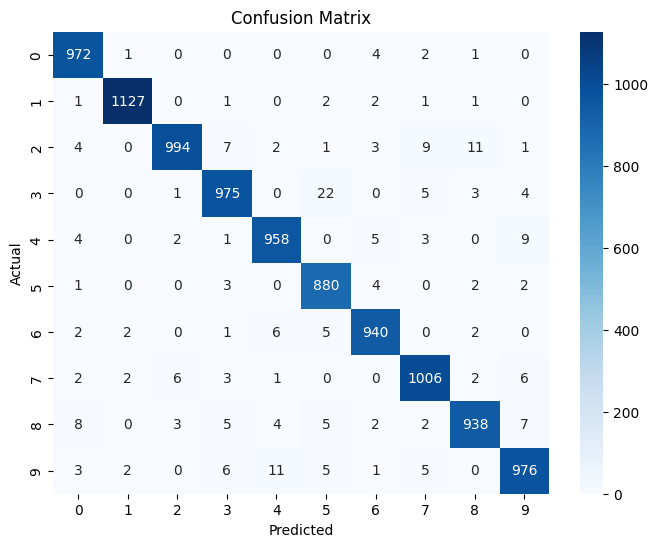

In [42]:
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()